### 2. This is my AI PC
<video width="960" height="540" 
       src="./media/video-2.1.mp4"  
       controls>
</video>

### Import all the required libraries

In [6]:
import numpy as np
import logging as log
import sys
import bm_utils as utils
from IPython.display import HTML
import cv2
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

import openvino as ov

In [3]:
!pip install pandas opencv-python matplotlib gradio


  Using cached opencv_python-4.13.0.92-cp37-abi3-manylinux_2_28_x86_64.whl.metadata (19 kB)
  Using cached matplotlib-3.10.8-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (52 kB)
  Using cached gradio-6.9.0-py3-none-any.whl.metadata (16 kB)
  Using cached contourpy-1.3.3-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached kiwisolver-1.5.0-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (5.1 kB)
  Using cached pillow-12.1.1-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (8.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
  Using cached aiofiles-24.1.0-py3-none-any.whl.metadata (10 kB)
  Using cached brotli-1.2.0-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (6.1 kB)
  Using cached fastapi-0.135.1-py3-none-any.whl.metadata (30 kB)
  Using cached ffmpy-1.0.0-py3-none-any.whl.met

<video width="960" height="540" 
       src="./media/video-2.2.mp4"  
       controls>
</video>

### Initialize OpenVINO
#### Check for available devices in the system

In [7]:
# Initialize OpenVINO
core = ov.Core()

available_devices=core.available_devices
print(available_devices)

['CPU', 'GPU', 'NPU']


#### Check for devices properties

In [8]:
for device in core.available_devices:
    print("Device full name: ", core.get_property(device, "FULL_DEVICE_NAME"))
    print("Supported formats: ",  core.get_property(device, "OPTIMIZATION_CAPABILITIES")) 
    print("Range for multiple streams: ", core.get_property(device, "RANGE_FOR_STREAMS"))

          
    print("-------------------------")
    

Device full name:  Intel(R) Core(TM) Ultra 5 125H
Supported formats:  ['FP32', 'INT8', 'BIN', 'EXPORT_IMPORT']
Range for multiple streams:  (1, 18)
-------------------------
Device full name:  Intel(R) Arc(TM) Graphics (iGPU)
Supported formats:  ['FP32', 'BIN', 'FP16', 'INT8', 'GPU_USM_MEMORY', 'EXPORT_IMPORT']
Range for multiple streams:  (1, 2)
-------------------------
Device full name:  Intel(R) AI Boost
Supported formats:  ['FP16', 'INT8', 'EXPORT_IMPORT']
Range for multiple streams:  (1, 4)
-------------------------


<video width="960" height="540" 
       src="./media/video-2.3.mp4"  
       controls>
</video>

### Load and compile a model

In [10]:
#read a model
model = core.read_model("models/ATSS-MobileNetV2/FP16/model.bin")

#compile the model
compiled_model = core.compile_model(model=model, device_name="CPU")

input_layer = compiled_model.input(0)
output_layer = compiled_model.output(0)

[libprotobuf ERROR ../../../../../repos/openvino/thirdparty/protobuf/protobuf/src/google/protobuf/text_format.cc:337] Error parsing text-format tensorflow.GraphDef: 1:1: Invalid control characters encountered in text.
[libprotobuf ERROR ../../../../../repos/openvino/thirdparty/protobuf/protobuf/src/google/protobuf/text_format.cc:337] Error parsing text-format tensorflow.GraphDef: 1:2: Interpreting non ascii codepoint 208.
[libprotobuf ERROR ../../../../../repos/openvino/thirdparty/protobuf/protobuf/src/google/protobuf/text_format.cc:337] Error parsing text-format tensorflow.GraphDef: 1:2: Expected identifier, got: �
[libprotobuf ERROR ../../../../../repos/openvino/thirdparty/protobuf/protobuf/src/google/protobuf/text_format.cc:337] Error parsing text-format tensorflow.GraphDef: 1:1: Invalid control characters encountered in text.
[libprotobuf ERROR ../../../../../repos/openvino/thirdparty/protobuf/protobuf/src/google/protobuf/text_format.cc:337] Error parsing text-format tensorflow.Gra

RuntimeError: Exception from src/inference/src/cpp/core.cpp:93:
Exception from src/inference/src/model_reader.cpp:160:
Unable to read the model: models/ATSS-MobileNetV2/FP16/model.bin Please check that model format: bin is supported and the model is correct. Available frontends: jax ir pytorch onnx tf paddle tflite 



### Load an image, resize it to fit model size

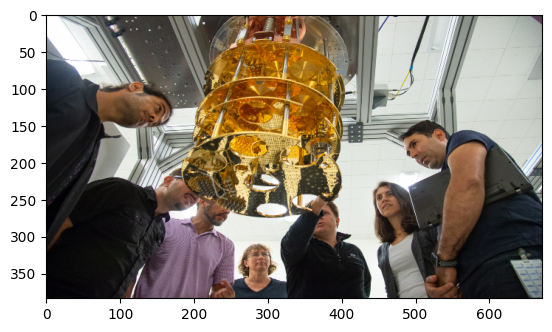

In [7]:
# Resize the image to the shape of the model's input layer
# The utils function displays the resized image before it's transposed for input into the model

image = cv2.imread("media/2.jpg")    #⏪⏪⏪⏪⏪  You can use any image in "media" folder (1.jpg, 2.jpg ...)


input_image, height, width = utils.resize_image(image, input_layer.shape)

### Perform inference

In [24]:
THRESH=0.2   #⏪⏪⏪⏪⏪  You can play with the threshold (values between 0 to 1)

# Create an inference request.
boxes = compiled_model([input_image])[output_layer]

#finding the boxes with high enough score
boxes=boxes.squeeze()[:,-5:]

boxes=np.array([x[-4:] for x in boxes if x[0]>THRESH])   #take only boxes that confidence>THRESH

#scaling cordinates back to original size
boxes=boxes*np.array([width,height,width,height])
boxes=boxes.astype(np.int64)


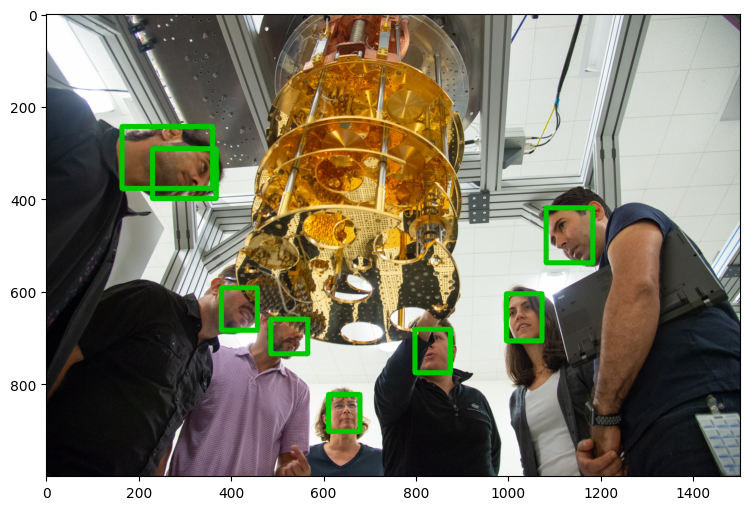

In [25]:
plt.figure(figsize=(10, 6))
final_image=utils.draw(image, boxes)
plt.imshow(cv2.cvtColor(final_image, cv2.COLOR_BGR2RGB))

<video width="960" height="540" 
       src="./media/video-2.4.mp4"  
       controls>
</video>

### Run benchmarks to check for throughput

In [5]:
throughput_demo = utils.build_gr_blocks(available_devices, goal="Throughput")   
throughput_demo.launch()

* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.


<video width="960" height="540" 
       src="./media/video-2.5.mp4"  
       controls>
</video>

### Run benchmarks to check for Latency

In [ ]:
latency_demo = utils.build_gr_blocks(available_devices, goal="Latency")   
latency_demo.launch()

# To see the benchmark_app command and arguments used for each run: 
#     in the Jupyter menu, select View->Show Log Console, and in the Console set log level to Info

<video width="960" height="540" 
       src="./media/video-2.6.mp4"  
       controls>
</video>

---

---